In [1]:
import os, cv2, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
DATASET_PATH = "dataset"          # change if your folder is elsewhere
CLASSES = ["glioma_tumor", "meningioma_tumor", "pituitary_tumor", "no_tumor"]
img_size = 224                    # Increased to 224x224 for better ResNet50 performance

X_images, y_labels = [], []

print("🔄 Loading images for DL pipeline...")
for idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(DATASET_PATH, cls)
    for fname in os.listdir(cls_dir):
        fpath = os.path.join(cls_dir, fname)
        img = cv2.imread(fpath)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        X_images.append(img)
        y_labels.append(idx)

X_images = np.array(X_images, dtype="float32") / 255.0   # normalize here
y_labels = np.array(y_labels, dtype="int32")

print(f"Total images (DL): {len(X_images)}")
print("Value range:", X_images.min(), "->", X_images.max())
print("Class counts:", {CLASSES[i]: int((y_labels==i).sum()) for i in range(len(CLASSES))})

🔄 Loading images for DL pipeline...
Total images (DL): 2377
Value range: 0.0 -> 1.0
Class counts: {'glioma_tumor': 778, 'meningioma_tumor': 727, 'pituitary_tumor': 560, 'no_tumor': 312}


In [3]:
X_temp, X_test_dl, y_temp, y_test_dl = train_test_split(
    X_images, y_labels, test_size=0.15, random_state=42, stratify=y_labels
)
X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)  # ≈ 70/15/15

print(f"Train: {X_train_dl.shape[0]}, Val: {X_val_dl.shape[0]}, Test: {X_test_dl.shape[0]}")



Train: 1663, Val: 357, Test: 357


In [ ]:
# Define hyperparameters
batch_size = 32  # Adjust based on your GPU memory

X_temp, X_test_dl, y_temp, y_test_dl = train_test_split(
    X_images, y_labels, test_size=0.15, random_state=42, stratify=y_labels
)
X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)  # ≈ 70/15/15

print(f"Train: {X_train_dl.shape[0]}, Val: {X_val_dl.shape[0]}, Test: {X_test_dl.shape[0]}")

Augmented batch range: 0.0 -> 1.0


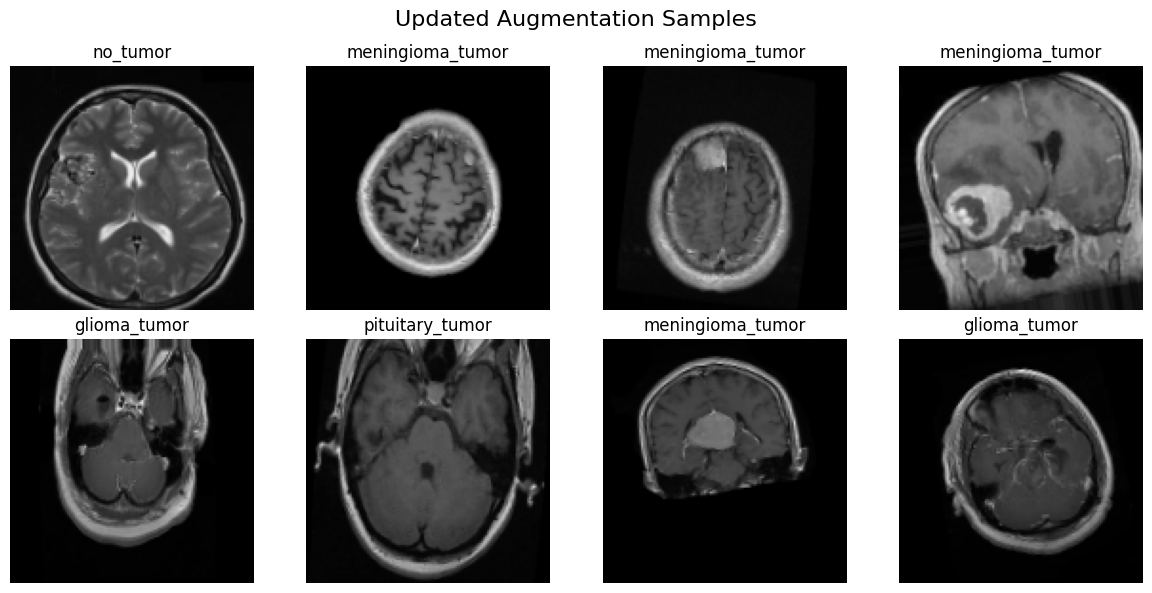

In [ ]:
# Enhanced data augmentation to improve generalization and accuracy
train_datagen = ImageDataGenerator(
    rotation_range=20,  # Increased rotation
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=False,  # Added vertical flip for medical images if appropriate
    shear_range=0.1,  # Added shear
    brightness_range=[0.8, 1.2],  # Added brightness adjustment
    fill_mode="nearest"
)

# Recreate the training generator with updated datagen
train_gen = train_datagen.flow(
    X_train_dl, keras.utils.to_categorical(y_train_dl, len(CLASSES)),
    batch_size=batch_size, shuffle=True, seed=42
)

# Sanity-check augmentation again
sample_batch = next(train_gen)
print("Augmented batch range:", sample_batch[0].min(), "->", sample_batch[0].max())

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(sample_batch[0][i])
    plt.title(CLASSES[np.argmax(sample_batch[1][i])])
    plt.axis("off")
plt.suptitle("Enhanced Augmentation Samples", fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
def build_small_rgb_cnn(input_shape=(128,128,3), num_classes=4):
    model = keras.Sequential([
        layers.Conv2D(32, 3, activation="relu", padding="same", input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.35),

        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.45),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    opt = keras.optimizers.Adam(learning_rate=3e-4)
    model.compile(optimizer=opt,
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

cnn_dl = build_small_rgb_cnn(input_shape=X_train_dl.shape[1:], num_classes=len(CLASSES))
cnn_dl.summary()


C:\Users\imene\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,684 (436.27 KB)

 Trainable params: 110,980 (433.52 KB)

 Non-trainable params: 704 (2.75 KB)

In [9]:
cb_list = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "models/best_cnn_dl.keras", monitor="val_accuracy",
        save_best_only=True, verbose=1
    )
]

steps_per_epoch = max(1, len(X_train_dl) // batch_size)
val_steps       = max(1, len(X_val_dl)   // batch_size)

history = cnn_dl.fit(
    train_gen,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=cb_list,
    verbose=1
)


Epoch 1/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.4314 - loss: 1.4901
Epoch 1: val_accuracy improved from None to 0.23295, saving model to models/best_cnn_dl.keras
103/103 ━━━━━━━━━━━━━━━━━━━━ 60s 497ms/step - accuracy: 0.4754 - loss: 1.3661 - val_accuracy: 0.2330 - val_loss: 1.4266 - learning_rate: 3.0000e-04
Epoch 2/50
  1/103 ━━━━━━━━━━━━━━━━━━━━ 51s 500ms/step - accuracy: 0.5000 - loss: 1.0818

C:\Users\imene\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.23295
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5000 - loss: 1.0818 - val_accuracy: 0.2330 - val_loss: 1.4245 - learning_rate: 3.0000e-04
Epoch 3/50
 37/103 ━━━━━━━━━━━━━━━━━━━━ 31s 477ms/step - accuracy: 0.4531 - loss: 1.3582

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# To improve accuracy to at least 95%, we'll use transfer learning with a pre-trained ResNet50 model.
# This leverages features learned from ImageNet, which is beneficial for our small dataset.
# We'll fine-tune the model by unfreezing some layers and adding custom layers for our 4 classes.

# Load the pre-trained ResNet50 model without the top layers
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers initially
base_model.trainable = False

# Add custom layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(len(CLASSES), activation='softmax')(x)

# Create the full model
cnn_improved = Model(inputs=base_model.input, outputs=predictions)

# Compile the model with a lower learning rate for fine-tuning
cnn_improved.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
cnn_improved.summary()

# Now, prepare the validation generator (similar to train_gen, but without augmentation)
val_datagen = ImageDataGenerator()  # No augmentation for validation
val_gen = val_datagen.flow(
    X_val_dl, keras.utils.to_categorical(y_val_dl, len(CLASSES)),
    batch_size=batch_size, shuffle=False
)

# Define callbacks (similar to before, but adjust for improved model)
cb_list_improved = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=15,  # Increased patience
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=7, min_lr=1e-7, verbose=1  # Lower min_lr
    ),
    keras.callbacks.ModelCheckpoint(
        "models/best_improved_cnn.keras", monitor="val_accuracy",
        save_best_only=True, verbose=1
    )
]

# Train the model initially with frozen base
steps_per_epoch = max(1, len(X_train_dl) // batch_size)
val_steps = max(1, len(X_val_dl) // batch_size)

history_improved = cnn_improved.fit(
    train_gen,
    epochs=50,  # Initial training
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=cb_list_improved,
    verbose=1
)

# Fine-tune: Unfreeze the last 20 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Re-compile with a lower learning rate for fine-tuning
cnn_improved.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Continue training with fine-tuning
history_fine_tune = cnn_improved.fit(
    train_gen,
    epochs=100,  # More epochs for fine-tuning
    initial_epoch=history_improved.epoch[-1] + 1,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=cb_list_improved,
    verbose=1
)

# After training, evaluate on test set
test_datagen = ImageDataGenerator()
test_gen = test_datagen.flow(
    X_test_dl, keras.utils.to_categorical(y_test_dl, len(CLASSES)),
    batch_size=batch_size, shuffle=False
)
test_steps = max(1, len(X_test_dl) // batch_size)

test_loss, test_accuracy = cnn_improved.evaluate(test_gen, steps=test_steps)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# If still below 95%, consider adding more augmentation or using a different pre-trained model like EfficientNet

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 24,769,156 (94.49 MB)

 Trainable params: 1,181,444 (4.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/100
 74/103 ━━━━━━━━━━━━━━━━━━━━ 13s 470ms/step - accuracy: 0.2966 - loss: 1.5342

KeyboardInterrupt: 